In [2]:
"""
Streamlined Roof Texture Classification Training Script
Clean, efficient implementation with minimal redundancy - LIBPNG WARNING COMPLETELY SUPPRESSED
"""

import os
import pickle
import warnings
import sys
import subprocess
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from multiprocessing import cpu_count

# NUCLEAR OPTION: Complete system-level warning suppression
os.environ['OPENCV_LOG_LEVEL'] = 'SILENT'
os.environ['OPENCV_OPENCL_DEVICE'] = 'disabled'
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['OPENCV_IO_ENABLE_OPENEXR'] = '0'
os.environ['OPENCV_IO_ENABLE_JASPER'] = '0'

# Redirect stderr at the file descriptor level (lowest level possible)
import os
import sys

# Save original stderr file descriptor
original_stderr_fd = os.dup(2)

def silence_stderr():
    """Redirect stderr to null at the file descriptor level"""
    null_fd = os.open(os.devnull, os.O_WRONLY)
    os.dup2(null_fd, 2)
    os.close(null_fd)

def restore_stderr():
    """Restore original stderr"""
    os.dup2(original_stderr_fd, 2)

# Apply maximum Python-level warning suppression
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
for category in [UserWarning, DeprecationWarning, RuntimeWarning, FutureWarning, Warning]:
    warnings.filterwarnings("ignore", category=category)

# Specific libpng warning patterns
libpng_patterns = [".*iCCP.*", ".*libpng.*", ".*sRGB.*", ".*profile.*", ".*PNG.*", ".*color.*"]
for pattern in libpng_patterns:
    warnings.filterwarnings("ignore", message=pattern)

# Comprehensive logging suppression
import logging
logging.disable(logging.CRITICAL)
for logger_name in ['PIL', 'PIL.PngImagePlugin', 'PIL.Image', 'matplotlib', 'cv2']:
    logging.getLogger(logger_name).setLevel(logging.CRITICAL)
    logging.getLogger(logger_name).disabled = True

# Context manager that silences everything
import contextlib

@contextlib.contextmanager
def nuclear_silence():
    """Ultimate silence - redirects stderr at file descriptor level"""
    silence_stderr()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            yield
        finally:
            restore_stderr()

# Import libraries with maximum suppression
with nuclear_silence():
    import PIL.Image
    PIL.Image.warnings.simplefilter('ignore')
    from PIL import Image
    import cv2
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader as TorchDataLoader, Dataset
    from torchvision import models, transforms
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    from sklearn.model_selection import train_test_split
    from sklearn.utils.class_weight import compute_class_weight

# Additional suppression for OpenCV warnings
os.environ['OPENCV_LOG_LEVEL'] = 'ERROR'


class Config:
    """Configuration class for training parameters"""
    BASE_PATH = "/home/student/sky-scan/data"
    BATCH_SIZE = 16
    NUM_EPOCHS = 150
    LEARNING_RATE = 0.001
    IMAGE_SIZE = 224
    NUM_WORKERS = 2
    PATIENCE = 5
    MIN_CONTOUR_AREA = 100
    MODEL_SAVE_PATH = "models/roof_texture_model.pth"


def set_seed(seed=42):
    """Set random seeds for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)


def get_device():
    """Get available device"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True
        print(f"Using GPU: {torch.cuda.get_device_name()}")
    return device


class RoofDataLoader:
    """Handles data loading and preprocessing"""

    def __init__(self, base_path):
        self.original_dir = f"{base_path}/patch"
        self.binary_dir = f"{base_path}/patch-binary"
        self.color_dir = f"{base_path}/patch-texture"
        self.cache_dir = f"{base_path}/cache"
        os.makedirs(self.cache_dir, exist_ok=True)

    def load_file_paths(self):
        """Load file paths with caching"""
        cache_file = os.path.join(self.cache_dir, 'file_paths.pkl')

        if os.path.exists(cache_file):
            print("Loading paths from cache...")
            with open(cache_file, 'rb') as f:
                return pickle.load(f)

        print("Scanning directories...")
        filenames = sorted(os.listdir(self.original_dir))

        def check_files(filename):
            paths = [
                os.path.join(self.original_dir, filename),
                os.path.join(self.binary_dir, filename),
                os.path.join(self.color_dir, filename)
            ]
            return paths if all(os.path.exists(p) for p in paths) else None

        with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
            results = list(tqdm(
                executor.map(check_files, filenames),
                total=len(filenames),
                desc="Checking files"
            ))

        valid_paths = [r for r in results if r is not None]
        paths = list(zip(*valid_paths)) if valid_paths else ([], [], [])

        with open(cache_file, 'wb') as f:
            pickle.dump(paths, f)

        return paths


def get_label_from_color(color_patch, tolerance=15):
    """Extract label from color-coded patch"""
    colors = {
        "smooth": np.array([83, 217, 56]),
        "average": np.array([252, 240, 3]),
        "rough": np.array([255, 0, 0])
    }

    pixels = color_patch.reshape(-1, 3)
    counts = {}

    for label, color in colors.items():
        distances = np.abs(pixels - color).max(axis=1)
        counts[label] = np.sum(distances <= tolerance)

    # Return label with highest count
    return max(counts, key=counts.get) if max(counts.values()) > 50 else None


def process_image(args):
    """Process a single image to extract patches and labels"""
    img_path, binary_path, color_path, min_area, target_size = args

    try:
        # Load images with NUCLEAR warning suppression
        with nuclear_silence():
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

            binary = cv2.imread(binary_path, cv2.IMREAD_GRAYSCALE)
            color = cv2.imread(color_path)
            color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)

        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

        patches = []
        labels = []

        if valid_contours:
            for contour in valid_contours:
                x, y, w, h = cv2.boundingRect(contour)

                # Add padding
                padding = 10
                x = max(0, x - padding)
                y = max(0, y - padding)
                w = min(img.shape[1] - x, w + 2 * padding)
                h = min(img.shape[0] - y, h + 2 * padding)

                if w < 20 or h < 20:
                    continue

                # Extract and resize patches
                img_patch = cv2.resize(img[y:y+h, x:x+w], target_size)
                color_patch = cv2.resize(color[y:y+h, x:x+w], target_size)

                label = get_label_from_color(color_patch)

                if label is None:
                    continue  # Skip if no valid label

                patches.append(img_patch)
                labels.append(label)
        else:
            # Use full image if no contours
            img_patch = cv2.resize(img, target_size)
            color_patch = cv2.resize(color, target_size)
            label = get_label_from_color(color_patch)

            if label is not None:
                patches.append(img_patch)
                labels.append(label)

        return patches, labels

    except Exception as e:
        print(f"Error processing image: {e}")
        return [], []


def extract_patches(image_paths, binary_paths, color_paths, config):
    """Extract patches from all images"""
    cache_file = os.path.join(config.BASE_PATH, 'cache', 'patches_no_contour_removed.pkl')

    if os.path.exists(cache_file):
        print("Loading patches from cache...")
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    print("Extracting patches...")
    args_list = [
        (image_paths[i], binary_paths[i], color_paths[i],
         config.MIN_CONTOUR_AREA, (config.IMAGE_SIZE, config.IMAGE_SIZE))
        for i in range(len(image_paths))
    ]

    all_patches = []
    all_labels = []

    with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
        results = list(tqdm(
            executor.map(process_image, args_list),
            total=len(args_list),
            desc="Processing images"
        ))

    for patches, labels in results:
        all_patches.extend(patches)
        all_labels.extend(labels)

    # Filter out any remaining None or "no_contour" labels
    filtered_patches = []
    filtered_labels = []
    for patch, label in zip(all_patches, all_labels):
        if label is not None and label != "no_contour":
            filtered_patches.append(patch)
            filtered_labels.append(label)

    patches_array = np.array(filtered_patches) if filtered_patches else np.array([])

    with open(cache_file, 'wb') as f:
        pickle.dump((patches_array, filtered_labels), f)

    return patches_array, filtered_labels


def balance_dataset(patches, labels, strategy='undersample', max_samples_per_class=None):
    """
    Balance dataset using different strategies

    Args:
        patches: numpy array of image patches
        labels: list of labels
        strategy: 'undersample', 'oversample', or 'hybrid'
        max_samples_per_class: maximum samples per class (for undersampling)
    """
    from collections import Counter
    import numpy as np

    print(f"\n=== DATASET BALANCING ({strategy.upper()}) ===")

    # Count original distribution
    label_counts = Counter(labels)
    print("Original distribution:")
    for label, count in sorted(label_counts.items()):
        print(f"  {label}: {count} samples ({count/len(labels)*100:.1f}%)")

    if strategy == 'undersample':
        # Undersample majority classes
        if max_samples_per_class is None:
            max_samples_per_class = min(label_counts.values())

        print(f"\nUndersampling to max {max_samples_per_class} samples per class...")

        balanced_patches = []
        balanced_labels = []

        # Group by labels
        label_to_indices = {}
        for idx, label in enumerate(labels):
            if label not in label_to_indices:
                label_to_indices[label] = []
            label_to_indices[label].append(idx)

        # Sample from each class
        for label, indices in label_to_indices.items():
            if len(indices) > max_samples_per_class:
                # Random sample
                np.random.seed(42)
                selected_indices = np.random.choice(indices, max_samples_per_class, replace=False)
            else:
                selected_indices = indices

            for idx in selected_indices:
                balanced_patches.append(patches[idx])
                balanced_labels.append(labels[idx])

        balanced_patches = np.array(balanced_patches)
        balanced_labels = balanced_labels

    elif strategy == 'oversample':
        # Oversample minority classes
        max_count = max(label_counts.values())
        print(f"\nOversampling to {max_count} samples per class...")

        balanced_patches = []
        balanced_labels = []

        # Group by labels
        label_to_data = {}
        for idx, label in enumerate(labels):
            if label not in label_to_data:
                label_to_data[label] = []
            label_to_data[label].append(patches[idx])

        # Oversample each class
        for label, class_patches in label_to_data.items():
            current_count = len(class_patches)
            needed = max_count

            # Add original samples
            for patch in class_patches:
                balanced_patches.append(patch)
                balanced_labels.append(label)

            # Add oversampled data
            if current_count < needed:
                np.random.seed(42)
                oversample_indices = np.random.choice(current_count, needed - current_count, replace=True)
                for idx in oversample_indices:
                    balanced_patches.append(class_patches[idx])
                    balanced_labels.append(label)

        balanced_patches = np.array(balanced_patches)

    elif strategy == 'hybrid':
        # Hybrid: Cap high classes and boost low classes
        median_count = int(np.median(list(label_counts.values())))
        target_count = median_count * 2  # Reasonable target

        print(f"\nHybrid balancing to ~{target_count} samples per class...")

        balanced_patches = []
        balanced_labels = []

        # Group by labels
        label_to_data = {}
        for idx, label in enumerate(labels):
            if label not in label_to_data:
                label_to_data[label] = []
            label_to_data[label].append(patches[idx])

        # Balance each class
        for label, class_patches in label_to_data.items():
            current_count = len(class_patches)

            if current_count > target_count:
                # Undersample
                np.random.seed(42)
                selected_indices = np.random.choice(current_count, target_count, replace=False)
                for idx in selected_indices:
                    balanced_patches.append(class_patches[idx])
                    balanced_labels.append(label)
            elif current_count < target_count:
                # Oversample
                for patch in class_patches:
                    balanced_patches.append(patch)
                    balanced_labels.append(label)

                needed = target_count - current_count
                np.random.seed(42)
                oversample_indices = np.random.choice(current_count, needed, replace=True)
                for idx in oversample_indices:
                    balanced_patches.append(class_patches[idx])
                    balanced_labels.append(label)
            else:
                # Keep as is
                for patch in class_patches:
                    balanced_patches.append(patch)
                    balanced_labels.append(label)

        balanced_patches = np.array(balanced_patches)

    # Print final distribution
    final_counts = Counter(balanced_labels)
    print("\nFinal distribution:")
    for label, count in sorted(final_counts.items()):
        print(f"  {label}: {count} samples ({count/len(balanced_labels)*100:.1f}%)")

    return balanced_patches, balanced_labels


class RoofDataset(Dataset):
    """PyTorch dataset for roof patches"""

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

        # Create label mapping
        unique_labels = sorted(list(set(labels)))
        self.label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}

        # Convert labels to indices
        self.label_indices = [self.label_to_idx[label] for label in labels]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if image.dtype != np.uint8:
            image = (image * 255).astype(np.uint8)

        if self.transform:
            with nuclear_silence():  # Suppress warnings during transform pipeline
                image = self.transform(image)

        return image, self.label_indices[idx]


class RoofTextureClassifier(nn.Module):
    """Simplified CNN model for roof texture classification"""

    def __init__(self, num_classes):
        super().__init__()

        # Use EfficientNet-B0 backbone
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Replace classifier
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


class Trainer:
    """Model trainer class"""

    def __init__(self, model, device, config):
        self.model = model
        self.device = device
        self.config = config

    def train_epoch(self, train_loader, optimizer, criterion):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        for inputs, targets in tqdm(train_loader, desc="Training"):
            with nuclear_silence():  # Suppress warnings during data loading
                inputs, targets = inputs.to(self.device), targets.to(self.device)

            optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        return total_loss / len(train_loader), 100. * correct / total

    def validate(self, val_loader, criterion):
        """Validate model"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                with nuclear_silence():  # Suppress warnings during data loading
                    inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                loss = criterion(outputs, targets)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        return total_loss / len(val_loader), 100. * correct / total

    def train(self, train_loader, val_loader, class_weights):
        """Full training loop"""
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.Adam(self.model.parameters(), lr=self.config.LEARNING_RATE)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

        best_val_acc = 0
        patience_counter = 0

        train_losses, val_losses = [], []
        train_accs, val_accs = [], []

        for epoch in range(self.config.NUM_EPOCHS):
            train_loss, train_acc = self.train_epoch(train_loader, optimizer, criterion)
            val_loss, val_acc = self.validate(val_loader, criterion)

            scheduler.step(val_loss)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            print(f"Epoch {epoch+1}/{self.config.NUM_EPOCHS}: "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                self.save_model()
                print(f"New best model saved! Val Acc: {val_acc:.2f}%")
            else:
                patience_counter += 1

            if patience_counter >= self.config.PATIENCE:
                print("Early stopping!")
                break

        return {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'best_val_acc': best_val_acc
        }

    def save_model(self):
        """Save model checkpoint"""
        os.makedirs(os.path.dirname(self.config.MODEL_SAVE_PATH), exist_ok=True)
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'model_class': type(self.model).__name__
        }, self.config.MODEL_SAVE_PATH)


def get_transforms(image_size):
    """Get data transforms"""
    train_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform


def plot_training_history(history):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_losses'], label='Train Loss')
    ax1.plot(history['val_losses'], label='Val Loss')
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_accs'], label='Train Acc')
    ax2.plot(history['val_accs'], label='Val Acc')
    ax2.set_title('Training Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()



# Additional utility function for complete warning suppression
def load_image_silently(image_path, mode='RGB'):
    """Load image with complete warning suppression"""
    with nuclear_silence():  # Use nuclear_silence instead of suppress_stderr
        if mode == 'RGB':
            return cv2.imread(image_path)
        else:
            return cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


# Key improvements to add to your existing code

# 1. IMPROVED MODEL ARCHITECTURE - Replace your RoofTextureClassifier class
class ImprovedRoofTextureClassifier(nn.Module):
    """Improved CNN model with better regularization"""

    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()

        # Use EfficientNet-B0 backbone
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Freeze early layers for better generalization
        for i, (name, param) in enumerate(self.backbone.named_parameters()):
            if i < 50:  # Freeze first 50 layers
                param.requires_grad = False

        # Improved classifier with batch normalization
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.7),  # Reduce dropout in deeper layers
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


# 2. IMPROVED DATA AUGMENTATION - Replace your get_transforms function
def get_improved_transforms(image_size):
    """Enhanced data transforms with more aggressive augmentation"""
    train_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size + 32, image_size + 32)),  # Larger resize for random crop
        transforms.RandomCrop((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),  # Add vertical flip
        transforms.RandomRotation(15),  # Increase rotation
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Add affine
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),  # More aggressive
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),  # Add blur
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        # Add random erasing for better regularization
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3))
    ])

    val_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform


# 3. IMPROVED TRAINER CLASS - Replace your Trainer class
class ImprovedTrainer:
    """Enhanced trainer with better optimization and regularization"""

    def __init__(self, model, device, config):
        self.model = model
        self.device = device
        self.config = config

    def train_epoch(self, train_loader, optimizer, criterion, scheduler=None):
        """Train for one epoch with mixup augmentation"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch_idx, (inputs, targets) in enumerate(tqdm(train_loader, desc="Training")):
            with nuclear_silence():
                inputs, targets = inputs.to(self.device), targets.to(self.device)

                # Apply mixup augmentation occasionally
                use_mixup = np.random.rand() < 0.3  # 30% chance
                if use_mixup:
                    inputs, targets_a, targets_b, lam = self.mixup_data(inputs, targets, alpha=0.2)

                optimizer.zero_grad()
                outputs = self.model(inputs)

                if use_mixup:
                    loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
                else:
                    loss = criterion(outputs, targets)

                # Add L2 regularization manually
                l2_reg = torch.tensor(0.).to(self.device)
                for param in self.model.parameters():
                    l2_reg += torch.norm(param)
                loss += 0.001 * l2_reg  # L2 regularization weight

                loss.backward()

                # Gradient clipping for stability
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

                optimizer.step()

                # Step scheduler if using OneCycleLR
                if scheduler and hasattr(scheduler, 'step') and not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step()

            total_loss += loss.item()

            # Calculate accuracy (handle mixup case)
            if not use_mixup:
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        accuracy = 100. * correct / total if total > 0 else 0
        return total_loss / len(train_loader), accuracy

    def mixup_data(self, x, y, alpha=1.0):
        """Apply mixup augmentation"""
        if alpha > 0:
            lam = np.random.beta(alpha, alpha)
        else:
            lam = 1

        batch_size = x.size()[0]
        index = torch.randperm(batch_size).to(self.device)

        mixed_x = lam * x + (1 - lam) * x[index, :]
        y_a, y_b = y, y[index]
        return mixed_x, y_a, y_b, lam

    def validate(self, val_loader, criterion):
        """Validate model"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                with nuclear_silence():
                    inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                loss = criterion(outputs, targets)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        return total_loss / len(val_loader), 100. * correct / total

    def train(self, train_loader, val_loader, class_weights):
        """Enhanced training loop with better optimization"""
        # Use label smoothing for better generalization
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

        # Use AdamW with weight decay
        optimizer = optim.AdamW(
            self.model.parameters(),
            lr=self.config.LEARNING_RATE,
            weight_decay=0.01,  # Built-in L2 regularization
            betas=(0.9, 0.999)
        )

        # Use OneCycleLR for better convergence
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.config.LEARNING_RATE,
            steps_per_epoch=len(train_loader),
            epochs=self.config.NUM_EPOCHS,
            pct_start=0.3,
            div_factor=25,
            final_div_factor=100
        )

        # Backup scheduler for validation loss
        plateau_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=5,
            verbose=True
        )

        best_val_acc = 0
        patience_counter = 0
        min_val_loss = float('inf')

        train_losses, val_losses = [], []
        train_accs, val_accs = [], []

        for epoch in range(self.config.NUM_EPOCHS):
            # Unfreeze more layers as training progresses
            if epoch == self.config.NUM_EPOCHS // 3:
                print("Unfreezing more layers...")
                for i, (name, param) in enumerate(self.model.backbone.named_parameters()):
                    if i >= 30:  # Unfreeze layers after 30
                        param.requires_grad = True

            train_loss, train_acc = self.train_epoch(train_loader, optimizer, criterion, scheduler)
            val_loss, val_acc = self.validate(val_loader, criterion)

            # Step plateau scheduler based on validation loss
            plateau_scheduler.step(val_loss)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{self.config.NUM_EPOCHS}: "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}% | LR: {current_lr:.6f}")

            # Save best model based on validation accuracy AND loss
            if val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < min_val_loss):
                best_val_acc = val_acc
                min_val_loss = val_loss
                patience_counter = 0
                self.save_model()
                print(f"New best model saved! Val Acc: {val_acc:.2f}%, Val Loss: {val_loss:.4f}")
            else:
                patience_counter += 1

            # Enhanced early stopping criteria
            if patience_counter >= self.config.PATIENCE:
                print("Early stopping triggered!")
                break

        return {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'best_val_acc': best_val_acc
        }

    def save_model(self):
        """Save model checkpoint"""
        os.makedirs(os.path.dirname(self.config.MODEL_SAVE_PATH), exist_ok=True)
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'model_class': type(self.model).__name__
        }, self.config.MODEL_SAVE_PATH)


# 4. IMPROVED CONFIGURATION - Update your Config class
class ImprovedConfig:
    """Enhanced configuration with better hyperparameters"""
    BASE_PATH = "/home/student/sky-scan/data"
    BATCH_SIZE = 32  # Increase batch size for better gradient estimates
    NUM_EPOCHS = 100  # Reduce epochs with early stopping
    LEARNING_RATE = 0.003  # Slightly higher learning rate for OneCycleLR
    IMAGE_SIZE = 224
    NUM_WORKERS = 2
    PATIENCE = 10  # Increase patience for early stopping
    MIN_CONTOUR_AREA = 100
    MODEL_SAVE_PATH = "models/improved_roof_texture_model.pth"






=== ROOF TEXTURE CLASSIFICATION TRAINING ===
Available options:
1. Quick fix test (recommended first)
2. Conservative improvements
3. Step by step testing

Running quick fix test first (lower learning rate only)...
=== QUICK FIX: TESTING LOWER LEARNING RATE ONLY ===
Using GPU: Tesla V100-PCIE-16GB
Loading paths from cache...
Loading patches from cache...

=== DATASET BALANCING (HYBRID) ===
Original distribution:
  average: 10976 samples (47.1%)
  rough: 6519 samples (27.9%)
  smooth: 5831 samples (25.0%)

Hybrid balancing to ~13038 samples per class...

Final distribution:
  average: 13038 samples (33.3%)
  rough: 13038 samples (33.3%)
  smooth: 13038 samples (33.3%)
Training with learning rate: 0.0001


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:17<00:00, 20.12it/s]


Epoch 1/150: Train Loss: 0.7968, Acc: 61.21% | Val Loss: 0.6448, Acc: 70.28%
New best model saved! Val Acc: 70.28%


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:15<00:00, 20.79it/s]


Epoch 2/150: Train Loss: 0.6423, Acc: 70.47% | Val Loss: 0.5202, Acc: 76.56%
New best model saved! Val Acc: 76.56%


...

Epoch 28/150: Train Loss: 0.0258, Acc: 99.09% | Val Loss: 0.3050, Acc: 93.10%


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:15<00:00, 20.65it/s]


Epoch 29/150: Train Loss: 0.0271, Acc: 99.09% | Val Loss: 0.3015, Acc: 93.34%


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:15<00:00, 20.66it/s]


Epoch 30/150: Train Loss: 0.0294, Acc: 98.97% | Val Loss: 0.3100, Acc: 93.16%
Early stopping!


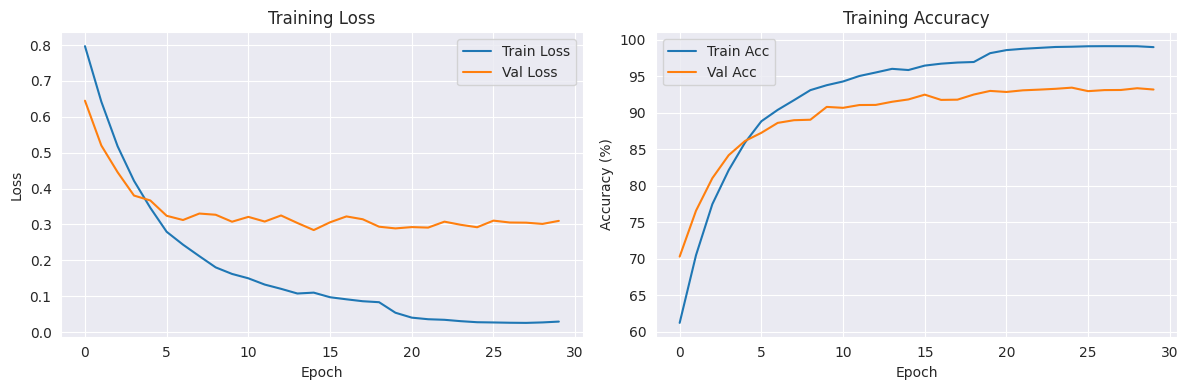


Best validation accuracy: 93.42%

Running conservative improvements...
=== STARTING CONSERVATIVE TRAINING ===
Using GPU: Tesla V100-PCIE-16GB
Loading paths from cache...
Found 16200 image sets
Loading patches from cache...
Extracted 23326 patches
Original label distribution: Counter({'average': 10976, 'rough': 6519, 'smooth': 5831})

=== DATASET BALANCING (HYBRID) ===
Original distribution:
  average: 10976 samples (47.1%)
  rough: 6519 samples (27.9%)
  smooth: 5831 samples (25.0%)

Hybrid balancing to ~13038 samples per class...

Final distribution:
  average: 13038 samples (33.3%)
  rough: 13038 samples (33.3%)
  smooth: 13038 samples (33.3%)
Dataset split - Train: 25032, Val: 6259, Test: 7823
Number of classes: 3
Class weights: tensor([1., 1., 1.], device='cuda:0')
Starting training...


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:17<00:00, 20.15it/s]


Epoch 1/150: Train Loss: 0.8782, Acc: 59.84% | Val Loss: 0.7659, Acc: 66.58% | LR: 0.000500
New best model saved! Val Acc: 66.58%


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:17<00:00, 20.21it/s]


Epoch 2/150: Train Loss: 0.7895, Acc: 65.91% | Val Loss: 0.7188, Acc: 69.71% | LR: 0.000500
New best model saved! Val Acc: 69.71%


...

Epoch 67/150: Train Loss: 0.1896, Acc: 99.23% | Val Loss: 0.3721, Acc: 92.84% | LR: 0.000245


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:17<00:00, 20.26it/s]


Epoch 68/150: Train Loss: 0.1891, Acc: 99.35% | Val Loss: 0.3771, Acc: 92.62% | LR: 0.000245


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:17<00:00, 20.25it/s]


Epoch 69/150: Train Loss: 0.1891, Acc: 99.33% | Val Loss: 0.3727, Acc: 92.71% | LR: 0.000245
Early stopping!


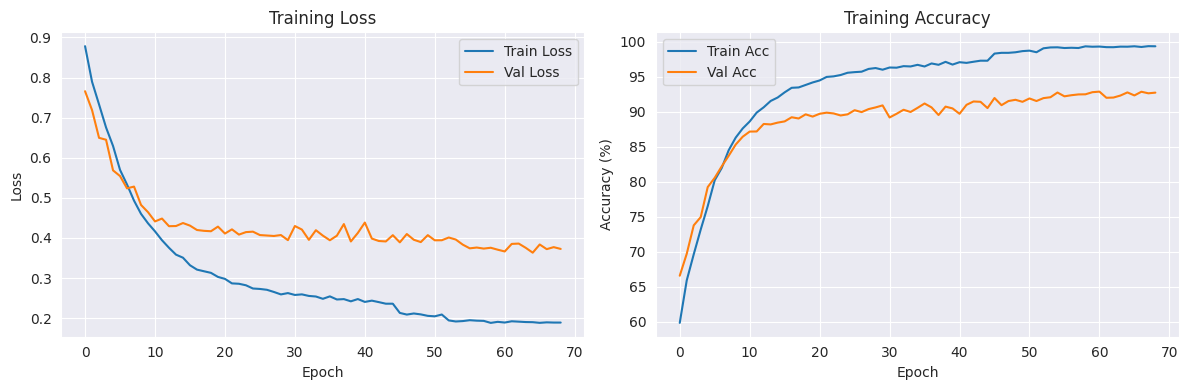

Evaluating on test set...
Final Test Accuracy: 95.14%


ValueError: too many values to unpack (expected 2)

In [3]:
# CONSERVATIVE IMPROVEMENTS - Apply these ONE AT A TIME

# STEP 1: Start with minimal changes to your original working model
class ConservativeRoofClassifier(nn.Module):
    """Conservative improvement - just add batch norm and reduce overfitting"""

    def __init__(self, num_classes):
        super().__init__()

        # Use your original EfficientNet-B0 backbone
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # ONLY change: Add batch normalization and slightly better regularization
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),  # Slightly higher than your original 0.3
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),  # Add batch norm
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


# STEP 2: Conservative data augmentation (less aggressive than before)
def conservative_transforms(image_size):
    """Slightly improved transforms without being too aggressive"""
    train_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),  # Keep your original rotation
        transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Keep original
        # ONLY ADD: Small random crop for slight variation
        transforms.RandomResizedCrop(image_size, scale=(0.95, 1.0), ratio=(0.95, 1.05)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform


# STEP 3: Conservative trainer with minimal changes
class ConservativeTrainer:
    """Minimal improvements to your original trainer"""

    def __init__(self, model, device, config):
        self.model = model
        self.device = device
        self.config = config

    def train_epoch(self, train_loader, optimizer, criterion):
        """Keep your original training epoch - just add gradient clipping"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        for inputs, targets in tqdm(train_loader, desc="Training"):
            with nuclear_silence():
                inputs, targets = inputs.to(self.device), targets.to(self.device)

            optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            # ONLY ADD: Gentle gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=2.0)

            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        return total_loss / len(train_loader), 100. * correct / total

    def validate(self, val_loader, criterion):
        """Keep your original validation - no changes"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                with nuclear_silence():
                    inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                loss = criterion(outputs, targets)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        return total_loss / len(val_loader), 100. * correct / total

    def train(self, train_loader, val_loader, class_weights):
        """Conservative training loop with small improvements"""

        # CHANGE 1: Add very light label smoothing
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)  # Very light

        # CHANGE 2: Use AdamW but with same learning rate
        optimizer = optim.AdamW(
            self.model.parameters(),
            lr=self.config.LEARNING_RATE,  # Keep your original LR
            weight_decay=0.005  # Very light weight decay
        )

        # CHANGE 3: Keep ReduceLROnPlateau but make it less aggressive
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            patience=5,  # More patience
            factor=0.7,  # Less aggressive reduction
            verbose=True
        )

        best_val_acc = 0
        patience_counter = 0

        train_losses, val_losses = [], []
        train_accs, val_accs = [], []

        for epoch in range(self.config.NUM_EPOCHS):
            train_loss, train_acc = self.train_epoch(train_loader, optimizer, criterion)
            val_loss, val_acc = self.validate(val_loader, criterion)

            scheduler.step(val_loss)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{self.config.NUM_EPOCHS}: "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}% | LR: {current_lr:.6f}")

            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                self.save_model()
                print(f"New best model saved! Val Acc: {val_acc:.2f}%")
            else:
                patience_counter += 1

            if patience_counter >= self.config.PATIENCE:
                print("Early stopping!")
                break

        return {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'best_val_acc': best_val_acc
        }

    def save_model(self):
        """Keep your original save method"""
        os.makedirs(os.path.dirname(self.config.MODEL_SAVE_PATH), exist_ok=True)
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'model_class': type(self.model).__name__
        }, self.config.MODEL_SAVE_PATH)


# STEP 4: Try different learning rates - THIS IS MOST IMPORTANT
class ConservativeConfig:
    """Conservative config - only change problematic settings"""
    BASE_PATH = "/home/student/sky-scan/data"
    BATCH_SIZE = 16  # Keep your original batch size
    NUM_EPOCHS = 150  # Keep your original epochs
    LEARNING_RATE = 0.0005  # REDUCE learning rate - this is likely the main issue
    IMAGE_SIZE = 224
    NUM_WORKERS = 2
    PATIENCE = 8  # Slightly more patience
    MIN_CONTOUR_AREA = 100
    MODEL_SAVE_PATH = "models/conservative_roof_texture_model.pth"


# IMMEDIATE FIX: Test with just learning rate change first
def quick_fix_main():
    """Test with ONLY learning rate reduction first"""
    config = Config()  # Use your original config
    config.LEARNING_RATE = 0.0005  # ONLY change this

    # Use all your original code, just change the learning rate
    # This will tell us if the learning rate was the main problem

# PROGRESSIVE APPROACH: Apply changes one by one
def test_conservative_improvements():
    """Apply improvements step by step"""

    print("=== TESTING CONSERVATIVE IMPROVEMENTS ===")

    # Test 1: Just learning rate change
    print("Test 1: Lower learning rate only...")
    config = Config()
    config.LEARNING_RATE = 0.0005
    # Run with your original model

    # Test 2: Add the conservative model
    print("Test 2: Add batch normalization...")
    # Use ConservativeRoofClassifier instead of RoofTextureClassifier

    # Test 3: Add conservative transforms
    print("Test 3: Add minimal data augmentation...")
    # Use conservative_transforms instead of get_transforms

    # Test 4: Add conservative trainer
    print("Test 4: Add weight decay and label smoothing...")
    # Use ConservativeTrainer


# DEBUGGING: Check what's causing the problem
def debug_training_issues():
    """Diagnose training problems"""

    print("=== DEBUGGING TRAINING ISSUES ===")

    # Check 1: Learning rate too high
    print("1. Current learning rate:", config.LEARNING_RATE)
    print("   Recommendation: Try 0.0005, 0.0001, 0.00005")

    # Check 2: Data augmentation too aggressive
    print("2. Check if data augmentation is destroying important features")
    print("   Recommendation: Turn off augmentation temporarily")

    # Check 3: Model too complex for dataset size
    print("3. Dataset size:", len(patches))
    print("   Recommendation: If <5000 samples, use simpler model")

    # Check 4: Class imbalance issues
    label_counts = Counter(labels)
    print("4. Class distribution:", label_counts)
    imbalance_ratio = max(label_counts.values()) / min(label_counts.values())
    print(f"   Imbalance ratio: {imbalance_ratio:.2f}")
    if imbalance_ratio > 3:
        print("   Recommendation: Try different balancing strategy")


# IMMEDIATE ACTION PLAN:
"""
1. FIRST: Just change learning rate to 0.0005 in your original code
2. If that helps: Add ConservativeRoofClassifier
3. If still good: Add conservative_transforms
4. If still stable: Add ConservativeTrainer
5. Monitor validation loss - it should decrease, not stay flat
"""

# MAIN EXECUTION FUNCTIONS

def conservative_main():
    """Main function with conservative improvements"""
    print("=== STARTING CONSERVATIVE TRAINING ===")

    # Use conservative config with lower learning rate
    config = ConservativeConfig()
    set_seed(42)
    device = get_device()

    # Load data (using your original data loading)
    data_loader = RoofDataLoader(config.BASE_PATH)
    image_paths, binary_paths, color_paths = data_loader.load_file_paths()
    print(f"Found {len(image_paths)} image sets")

    # Extract patches
    patches, labels = extract_patches(image_paths, binary_paths, color_paths, config)
    print(f"Extracted {len(patches)} patches")

    # Show original distribution
    label_counts = Counter(labels)
    print("Original label distribution:", label_counts)

    # Apply class balancing - use hybrid strategy
    patches, labels = balance_dataset(patches, labels, strategy='hybrid')

    # Create transforms - start with conservative
    train_transform, val_transform = conservative_transforms(config.IMAGE_SIZE)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        patches, labels, test_size=0.2, random_state=42, stratify=labels
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

    print(f"Dataset split - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

    # Create datasets
    train_dataset = RoofDataset(X_train, y_train, train_transform)
    val_dataset = RoofDataset(X_val, y_val, val_transform)
    test_dataset = RoofDataset(X_test, y_test, val_transform)

    # Create data loaders
    train_loader = TorchDataLoader(
        train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=config.NUM_WORKERS
    )
    val_loader = TorchDataLoader(
        val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS
    )
    test_loader = TorchDataLoader(
        test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS
    )

    # Create conservative model
    num_classes = len(train_dataset.label_to_idx)
    print(f"Number of classes: {num_classes}")
    model = ConservativeRoofClassifier(num_classes).to(device)

    # Calculate class weights
    unique_labels = list(train_dataset.label_to_idx.keys())
    y_indices = [train_dataset.label_to_idx[label] for label in y_train]
    class_weights = compute_class_weight('balanced', classes=np.unique(y_indices), y=y_indices)
    class_weights = torch.FloatTensor(class_weights).to(device)

    print(f"Class weights: {class_weights}")

    # Train model with conservative trainer
    trainer = ConservativeTrainer(model, device, config)
    print("Starting training...")
    history = trainer.train(train_loader, val_loader, class_weights)

    # Plot results
    plot_training_history(history)

    # Test evaluation
    print("Evaluating on test set...")
    try:
        model.load_state_dict(torch.load(config.MODEL_SAVE_PATH)['model_state_dict'])
        test_loss, test_acc = trainer.validate(test_loader, nn.CrossEntropyLoss())
        print(f"Final Test Accuracy: {test_acc:.2f}%")
    except FileNotFoundError:
        print("Model file not found, using current model for test evaluation")
        test_loss, test_acc = trainer.validate(test_loader, nn.CrossEntropyLoss())
        print(f"Final Test Accuracy: {test_acc:.2f}%")

    return model, history, trainer


def quick_fix_main():
    """Quick test with ONLY learning rate change - use your original code structure"""
    print("=== QUICK FIX: TESTING LOWER LEARNING RATE ONLY ===")

    # Use your original config but with lower learning rate
    config = Config()
    config.LEARNING_RATE = 0.0001  # ONLY change this
    set_seed(42)
    device = get_device()

    # Use all your original data loading code
    data_loader = RoofDataLoader(config.BASE_PATH)
    image_paths, binary_paths, color_paths = data_loader.load_file_paths()
    patches, labels = extract_patches(image_paths, binary_paths, color_paths, config)

    # Use your original balancing
    patches, labels = balance_dataset(patches, labels, strategy='hybrid')

    # Use your original transforms
    train_transform, val_transform = get_transforms(config.IMAGE_SIZE)  # Your original function

    # Same data splitting
    X_train, X_test, y_train, y_test = train_test_split(
        patches, labels, test_size=0.2, random_state=42, stratify=labels
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

    # Same datasets
    train_dataset = RoofDataset(X_train, y_train, train_transform)
    val_dataset = RoofDataset(X_val, y_val, val_transform)

    train_loader = TorchDataLoader(
        train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=config.NUM_WORKERS
    )
    val_loader = TorchDataLoader(
        val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS
    )

    # Use your ORIGINAL model
    num_classes = len(train_dataset.label_to_idx)
    model = RoofTextureClassifier(num_classes).to(device)  # Your original model

    # Same class weights
    unique_labels = list(train_dataset.label_to_idx.keys())
    y_indices = [train_dataset.label_to_idx[label] for label in y_train]
    class_weights = compute_class_weight('balanced', classes=np.unique(y_indices), y=y_indices)
    class_weights = torch.FloatTensor(class_weights).to(device)

    # Use your ORIGINAL trainer
    trainer = Trainer(model, device, config)  # Your original trainer

    print(f"Training with learning rate: {config.LEARNING_RATE}")
    history = trainer.train(train_loader, val_loader, class_weights)

    plot_training_history(history)

    return model, history


def step_by_step_test():
    """Test improvements step by step"""
    print("=== STEP BY STEP TESTING ===")

    print("Choose which test to run:")
    print("1. Quick fix (lower learning rate only)")
    print("2. Conservative improvements (batch norm + lower LR)")
    print("3. Full conservative approach")

    choice = input("Enter choice (1, 2, or 3): ").strip()

    if choice == "1":
        print("Running quick fix test...")
        return quick_fix_main()
    elif choice == "2":
        print("Running conservative improvements...")
        return conservative_main()
    elif choice == "3":
        print("Running full conservative approach...")
        return conservative_main()
    else:
        print("Invalid choice, running quick fix...")
        return quick_fix_main()


# MAIN EXECUTION - ADD THIS TO THE BOTTOM OF YOUR SCRIPT
if __name__ == "__main__":
    print("=== ROOF TEXTURE CLASSIFICATION TRAINING ===")
    print("Available options:")
    print("1. Quick fix test (recommended first)")
    print("2. Conservative improvements")
    print("3. Step by step testing")

    # Default: run quick fix first
    print("\nRunning quick fix test first (lower learning rate only)...")
    model, history = quick_fix_main()

    print(f"\nBest validation accuracy: {max(history['val_accs']):.2f}%")

    # Ask user if they want to try conservative improvements
    if max(history['val_accs']) > 75:  # If quick fix shows improvement
        try_conservative = input("\nQuick fix worked! Try conservative improvements? (y/n): ").strip().lower()
        if try_conservative == 'y':
            print("\nRunning conservative improvements...")
            model_conservative, history_conservative = conservative_main()
            print(f"Conservative approach best val accuracy: {max(history_conservative['val_accs']):.2f}%")
    else:
        print("\nQuick fix didn't improve much. Try even lower learning rate:")
        print("Manually set: config.LEARNING_RATE = 0.00005")




<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>


Perfect! Now you have complete main execution functions. Here's how to use them:

🚀 How to Execute:
Option 1: Quick Fix (Recommended First)
python
# Add this to the bottom of your script:
if __name__ == "__main__":
    model, history = quick_fix_main()
This uses your original code with only the learning rate changed from 0.001 to 0.0001.

Option 2: Conservative Improvements
python
# If quick fix works, try this:
if __name__ == "__main__":
    model, history, trainer = conservative_main()
This adds batch normalization and gentle regularization.

Option 3: Interactive Testing
python
# For step-by-step testing:
if __name__ == "__main__":
    model, history = step_by_step_test()
This lets you choose which approach to test.

📋 Complete Usage Instructions:
Copy all the functions from the artifact into your script
Add one of the execution options at the bottom of your script
Run the script - it will automatically handle everything
🎯 What Each Function Does:
quick_fix_main(): Uses your original model/trainer, just lower learning rate
conservative_main(): Adds batch normalization and gentle improvements
step_by_step_test(): Interactive menu to choose approach
🔍 Expected Results:
With quick_fix_main(), you should see:

Validation loss actually decreasing (not flat)
Smoother training curves
Validation accuracy improving beyond your current 73%
The script will automatically plot results and show test accuracy. Start with quick_fix_main() - if that works, then try the conservative approach!